### 📦 1. Imports

In [9]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

### 🔌 2. Connect to DB

In [10]:
conn = sqlite3.connect("../data/etl_rapid.db")

### 📥 3. Load Data

In [11]:
query = """
SELECT
    f.flight_number,
    f.arrival_year,
    f.arrival_month,
    f.arrival_day,
    f.arrival_hour,
    f.arrival_minute,
    a.iata_code AS airport
FROM flights f
JOIN airports a ON f.airport_id = a.id
"""

df = pd.read_sql(query, conn)

# Close connection
conn.close()

### 🧹 4. Data Preparation

In [12]:
# Convert to datetime
df["datetime"] = pd.to_datetime(
    df["arrival_year"] + "-" +
    df["arrival_month"] + "-" +
    df["arrival_day"] + " " +
    df["arrival_hour"] + ":" +
    df["arrival_minute"]
)

# Extract features
df["hour"] = df["datetime"].dt.hour
df["day"] = df["datetime"].dt.date

df.head()

,flight_number,arrival_year,arrival_month,arrival_day,arrival_hour,arrival_minute,airport,datetime,hour,day
0,A3 1591,2026,03,11,09,10,BER,2026-03-11 09:10:00,9,2026-03-11
1,A3 820,2026,03,11,09,31,BER,2026-03-11 09:31:00,9,2026-03-11
2,A3 821,2026,03,11,13,25,BER,2026-03-11 13:25:00,13,2026-03-11
3,AC 6763,2026,03,11,11,11,BER,2026-03-11 11:11:00,11,2026-03-11
4,AC 6797,2026,03,11,10,10,BER,2026-03-11 10:10:00,10,2026-03-11


### 📊 5. Flights per Airport

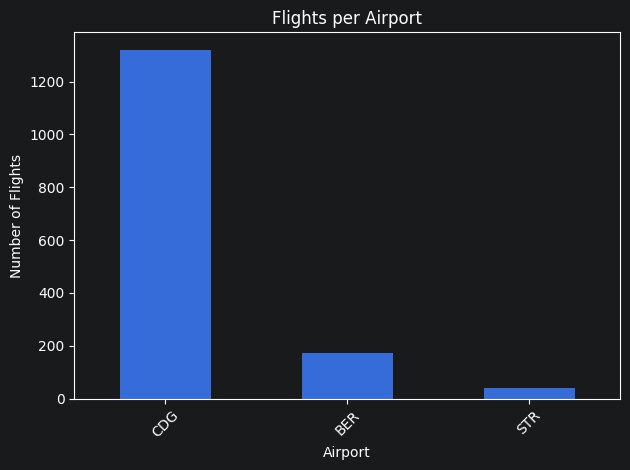

In [13]:
airport_counts = df["airport"].value_counts()

plt.figure()
airport_counts.plot(kind="bar")
plt.title("Flights per Airport")
plt.xlabel("Airport")
plt.ylabel("Number of Flights")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### ⏰ 6. Flights per Hour

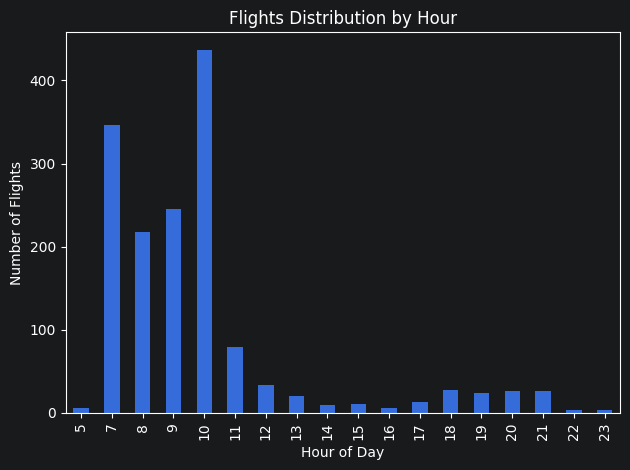

In [14]:
hour_counts = df["hour"].value_counts().sort_index()

plt.figure()
hour_counts.plot(kind="bar")
plt.title("Flights Distribution by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Flights")
plt.tight_layout()
plt.show()

### 📅 7. Flights per Day

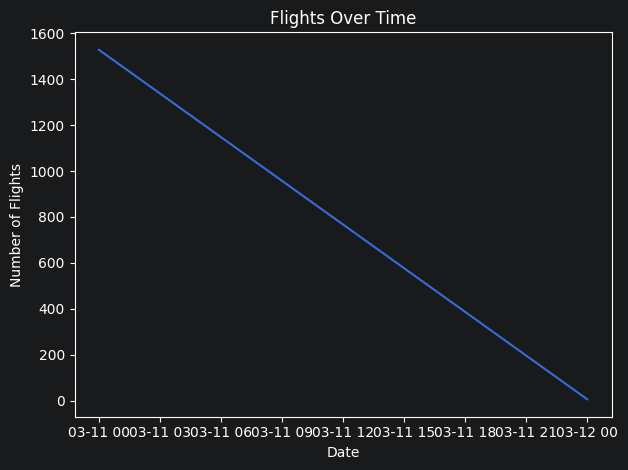

In [15]:
day_counts = df["day"].value_counts().sort_index()

plt.figure()
day_counts.plot(kind="line")
plt.title("Flights Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Flights")
plt.tight_layout()
plt.show()

### 🧠 8. Top Busy Hours per Airport

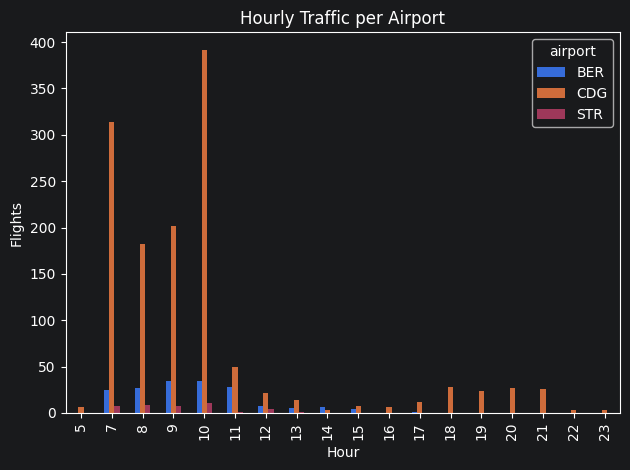

In [16]:
pivot = df.pivot_table(
    index="hour",
    columns="airport",
    values="flight_number",
    aggfunc="count"
)

pivot.plot(kind="bar")
plt.title("Hourly Traffic per Airport")
plt.xlabel("Hour")
plt.ylabel("Flights")
plt.tight_layout()
plt.show()

### 🔍 9. Basic Insights

In [17]:
print("Total flights:", len(df))
print("\nFlights per airport:")
print(df["airport"].value_counts())

print("\nPeak hour:")
print(df["hour"].value_counts().idxmax())

print("\nLeast busy hour:")
print(df["hour"].value_counts().idxmin())

Total flights: 1534

Flights per airport:
airport
CDG    1320
BER     173
STR      41
Name: count, dtype: int64

Peak hour:
10

Least busy hour:
23


### 🧠 Insights

In [18]:
print("📊 INSIGHTS")

# busiest airport
busiest_airport = df["airport"].value_counts().idxmax()
print(f"Most active airport: {busiest_airport}")

# peak hour
peak_hour = df["hour"].value_counts().idxmax()
print(f"Peak traffic hour: {peak_hour}:00")

# distribution
print("\nFlights distribution:")
print(df["hour"].value_counts().sort_index())

📊 INSIGHTS
Most active airport: CDG
Peak traffic hour: 10:00

Flights distribution:
hour
5       6
7     346
8     218
9     245
10    436
11     79
12     34
13     20
14      9
15     11
16      6
17     13
18     28
19     24
20     27
21     26
22      3
23      3
Name: count, dtype: int64
